## Plot the all clustering results for mocks

1. we compare the 2pt and 3pt measurements between clean and contaminated mocks

In [10]:
import os
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import sys
import random
import logging
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.table import Table,join,Column

from cosmoprimo.fiducial import DESI, AbacusSummit
from pycorr import TwoPointCorrelationFunction, setup_logging
from pycorr.corrfunc import CorrfuncTwoPointCounter
from pypower import CatalogFFTPower, PowerSpectrumMultipoles, setup_logging
from pycorr import project_to_multipoles, project_to_wp, TwoPointCorrelationFunction, setup_logging

sys.path.append('../../')
from helper import REDSHIFT_BIN_GLOBAL, REDSHIFT_BIN_LSS, NRAN_Y3, TRACER_CUTSKY_INFO
from helper import GET_REDSHIFT_SET
from cat_tools import read_positions_weights, get_measurement_fn, parse_zerr_name
from dv_tools import get_repeats_dv, get_cthr

from fit_tools import load_bins, read_data_from_fn
from plotting_tools import COLOR_OVERALL, TPS_LABELS
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   # Computer Modern-like math
    "font.family": "serif",
})

%load_ext autoreload
%autoreload 2
%matplotlib inline

BASE_DIR = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v1'
REPEAT_DIR = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
RESULT_DIR = '../results'
OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
SKIP_HOLI_ID_SET = np.loadtxt('/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/main/clustering/dubious_holi-v3-altmtl.txt', dtype=int)

def zfmt(x):
    return f"{x:.3f}".replace(".", "p")

def tps_to_array(tps, ells):
    if isinstance(tps, dict):
        return np.array([np.asarray(tps[ell]) for ell in ells])
    return np.atleast_2d(tps)

cosmo = DESI()
save_fig = True

setup_logging(level='warning')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
BIN_TYPE = 'y3_sys'
line_width = 1.5
alpha = 0.08

def get_error_bars(cov_args, corr, num=None, bin_type=BIN_TYPE, remove_bins=None, ):
    tps_fid_all = []
    if num is None:
        num = 1000 if cov_args['version'] == 'holi-v3' else 25
    for mock_id in range(num)[:]:
        if mock_id in SKIP_HOLI_ID_SET and cov_args['version'] == 'holi-v3':
            continue
        cov_args.update(mock_id=mock_id, use_dv=False, z_evol=False)
        fn_fid = get_measurement_fn(**cov_args)
        if 'mesh3' in corr and not os.path.exists(fn_fid.format('mesh3_spectrum_poles_sugiyama')):
            continue
        (s_fid, tps_fid), _ = read_data_from_fn(fn_fid, corr, bin_type=bin_type, remove_bins=remove_bins, verbose=False)
        if tps_fid is not None:
            tps_fid_all.append(tps_fid)
    tps_mean_fid = np.atleast_2d(tps_fid_all).mean(axis=0)
    tps_std_fid = np.atleast_2d(tps_fid_all).std(axis=0, ddof=1)
    error_bar = tps_std_fid
    # print(len(tps_fid_all))
    return error_bar

def include_data_xmax_tick(ax, xmax_data, fmt="{:.2g}"):
    xmin, xmax = ax.get_xlim()
    ticks = list(ax.get_xticks())
    ticks = [t for t in ticks if xmin <= t <= xmax]
    if not np.any(np.isclose(ticks, xmax_data)):
        ticks.append(xmax_data)
    ticks = sorted(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt.format(t) for t in ticks])

## Power spectrum compares

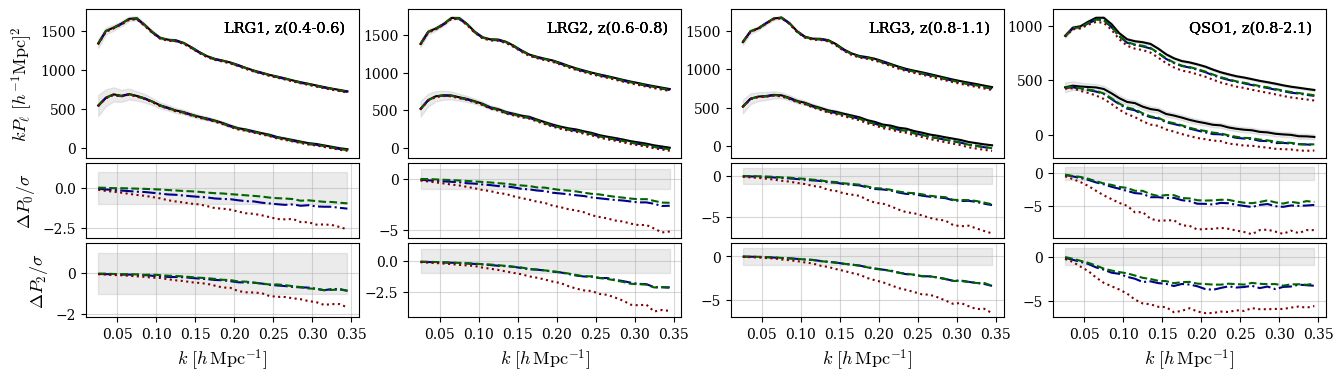

In [13]:
# for two point statistics
corr = 'mesh2' # xi, pk, mpslog, wplog, mesh2
domain = 'altmtl' # cubic, altmtl
version = 'AbacusHF-v2' # AbacusHF-v2, holi-v3
cov_version = 'holi-v3' # AbacusHF-v2, holi-v3
cov_num = 1000
tracers = ['LRG', 'QSO'][:]
# tracers = ['BGS', 'ELG'][:]
tracer_label = ''.join(t[0] for t in tracers)
# zerrs =  ['False', 'repeat', 'repeat_zevol', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']
zerrs =  ['False','verr_nonparam', 'verr_nonparam_zevol', 'repeat']
# labels =  ['clean', r'$+\Delta v_{\rm{error}}$', r'$+\Delta v_{\rm{error, zevol}}$', r'$+\Delta v_{\rm{repeats}}$']
labels =  ['Baseline', r'Contam. $v_{\rm{err}}$', r'Contam. $v_{\rm{err, zevol}}$', r'Contam. $\Delta v_{\rm{ij}}$']
# labels = ['clean', '+dv_repeat', '+dv_repeat_zevol', '+dv_err_empirical', '+dv_err_nonparam', '+dv_err_nonparam_zevol']
colors = ['black', 'darkblue', 'darkgreen', 'maroon', 'teal', 'orange']
lss = ['-', '-.', '--', ':']*len(zerrs)
zerr_labels = dict(zip(zerrs, labels))

use_jax = True if 'mesh' in corr else False
ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for indz, (zp, zr) in enumerate(zip(ZSNAPS[tracer][:], ZRANGES[tracer][:])):
        tracer_redshifts.append((f'{tracer}{indz+1}', zp, zr))
lenz = len(tracer_redshifts)

spow = 2 if corr in ['xi', 'wplog', 'mpslog'] else 1
n_ell = 1 if corr == 'wplog' else 2
fig = plt.figure(figsize=(lenz * 4, 4))
gs = gridspec.GridSpec(n_ell+1, lenz, wspace=0.18, hspace=0.06, height_ratios=[2]+[1]*n_ell)
for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):    
    if 'QSO' in tracer:
        version = 'AbacusHF-v2'
        domain = 'cutsky'
        hod = 'base_dv'
    elif 'BGS' in tracer:
        version = 'AbacusSecondGen'
        hod = 'base'
    else:
        version = 'AbacusHF-v2'
        domain = domain
        hod = 'base'
    data_arges = {'version':version, 'domain': domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False, "use_jax": use_jax, "hod": hod}   
    cov_args = {'version': cov_version, 'domain': 'altmtl', 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False, "use_jax": use_jax}
    error_bar = get_error_bars(cov_args, corr, num=cov_num, bin_type='test')
    for indv, zerr in enumerate(zerrs):
        ax_top = plt.subplot(gs[indz])
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25)[:]:
            data_arges.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            fn = get_measurement_fn(**data_arges)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test', verbose=False)
            # for ell in range(n_ell):
                # ax_top.plot(s, s**spow*tps[ell], color=colors[indv], lw = 0.2, alpha=0.2)
            tps = np.atleast_2d(tps)
            tps_all.append(tps)
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        tps_std = tps_all.std(axis=0, ddof=1)
        if zerr == 'False':
            tps_mean_fid = tps_mean
            tps_std_fid = tps_std
        # ax_top.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
        ax_top.text(0.95, 0.92,f'{tracer}, z({zrange[0]:.1f}-{zrange[1]:.1f})',transform=ax_top.transAxes, ha='right', va='top', fontsize=10.5, )
        ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        for ill in range(n_ell):
            # plot the mean plots
            if zerr == 'False':
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = '-',  lw = line_width, zorder=0, label=zerr_labels[zerr] if ill == 0 else None)
                ax_top.fill_between(s, s**spow*(tps_mean_fid[ill]-error_bar[ill]), s**spow*(tps_mean_fid[ill]+error_bar[ill]), color=colors[indv], alpha=alpha)
                # ax_top.errorbar(s, s**spow*tps_mean[ill], yerr=s**spow*error_bar[ill], fmt='o',linestyle='none', markersize=2, lw=1, color=colors[indv], label=zerr_labels[zerr] if ill == 0 else None)
            else:
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], lw = line_width, ls=lss[indv], label=zerr_labels[zerr] if ill == 0 else None)
            if corr in ['wplog', 'mpslog']:
                ax_top.set_xscale('log')
            if indz == 0:
                ax_top.set_ylabel(TPS_LABELS[corr]['y'], fontsize=13)
            # plot the residual plots
            if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
                if ill == 0:
                    ax_res = plt.subplot(gs[indz+lenz])
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy0'], fontsize=13)
                    if corr == 'wplog':
                        ax_res.set_xlabel(TPS_LABELS[corr]['x'])
                    ax_res.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                elif ill == 1:
                    ax_res = plt.subplot(gs[indz+lenz*2])
                    ax_res.set_xlabel(TPS_LABELS[corr]['x'], fontsize=13)
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy2'], fontsize=13)
                # ax.plot(s, s**spow*(tps_mean_clean[ill]-tps_mean[ill]), lw=1, color=colors[indv])  
                # continue
                # err = np.sqrt(tps_std_fid**2 + clean_std[ell]**2)
                diff = (tps_mean[ill]-tps_mean_fid[ill])/error_bar[ill]
                ax_res.plot(s, diff, lw=line_width, color=colors[indv], ls=lss[indv])
                # ax.plot(s, s*(tps_mean[ill]-tps_mean_clean[ill]), lw=1, color=colors[indv])  
                # for value in [-1,1]:
                    # ax_res.axhline(y=value, ls = ':', color='black', lw=1.5)
                if zerr == 'repeat':
                    ax_res.fill_between(s, -1, 1,  color='black', alpha=alpha)
                    if 'ELG' in tracer or 'BGS' in tracer: ax_res.set_ylim([-1.5,1.5])
                    if 'LRG' in tracer or 'QSO' in tracer: ax_res.set_ylim([min(diff)-0.5, 1.5])
                ax_res.grid(alpha=0.5)
                # if BIN_TYPE == 'folpsD':
                    # ax_res.axvline(x=0.35-ill*0.1, ls = '--', color='gray', lw=line_width)
xticks = np.arange(0.05, 0.35 + 0.001, 0.05)
for ax in fig.axes:
    ax.set_xticks(xticks)
    ax.set_xlim(0.01, 0.36)
if 'BGS' in tracers:
    handles, legend_labels = ax_top.get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=len(zerrs), fontsize=12, frameon=False)
if save_fig == True and len(tracers) == 2:
    plt.savefig(OVERLEAF_DIR+f'/plot_{corr}_{tracer_label}_clustering.pdf', bbox_inches='tight')
plt.show()

## Bispectrum compares

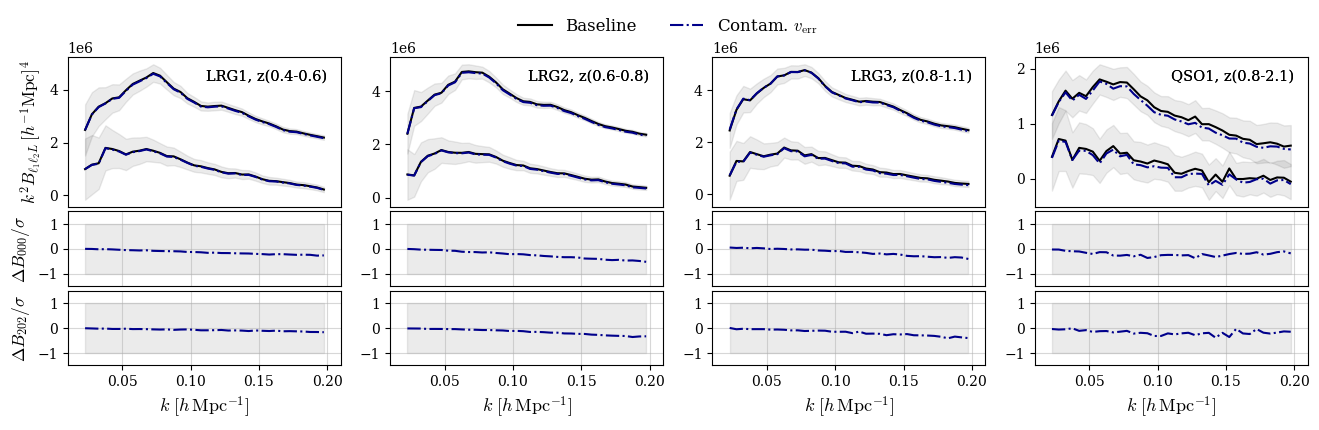

In [7]:
# for three point statistics
corr = 'mesh3_sugiyama' # 
ells=[(0, 0, 0), (2, 0, 2)]
domain = 'altmtl' # cubic, altmtl
version = 'AbacusHF-v2' # AbacusHF-v2, holi-v3
cov_version = 'holi-v3'
cov_num = 1000
tracers = ['LRG', 'QSO'][:]
# tracers = ['BGS', 'ELG'][1:]
tracer_label = ''.join(t[0] for t in tracers)
zerrs =  ['False','verr_nonparam', 'verr_nonparam_zevol', 'repeat'][:2]
labels =  ['Baseline', r'Contam. $v_{\rm{err}}$', r'Contam. $v_{\rm{err, zevol}}$', r'Contam. $\Delta v_{\rm{rep}}$']
# labels =  ['clean', r'$+\Delta v_{\rm{err}}$', r'$+\Delta v_{\rm{err, zevol}}$', r'$+\Delta v_{\rm{rep}}$'][:2]
# labels = ['clean', '+dv_repeat', '+dv_repeat_zevol', '+dv_err_empirical', '+dv_err_nonparam', '+dv_err_nonparam_zevol']
colors = ['black', 'darkblue', 'darkgreen', 'maroon', 'teal', 'orange']
lss = ['-', '-.', '--', ':']*len(zerrs)
zerr_labels = dict(zip(zerrs, labels))

use_jax = True if 'mesh' in corr else False
ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for indz, (zp, zr) in enumerate(zip(ZSNAPS[tracer][:], ZRANGES[tracer][:])):
        tracer_redshifts.append((f'{tracer}{indz+1}', zp, zr))
lenz = len(tracer_redshifts)

spow = 2
n_ell = len(ells)
fig = plt.figure(figsize=(lenz * 4, 4))
# fig = plt.figure(figsize=(lenz * 3.5, 3.))
gs = gridspec.GridSpec(n_ell+1, lenz, wspace=0.18, hspace=0.05, height_ratios=[2]+[1]*n_ell)

for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts): 
    if tracer == 'QSO': 
        domain = 'cutsky'
        hod = 'base_dv'
    else:
        domain = 'altmtl'
        hod = 'base'
    data_arges = {'version':version, 'domain': domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False, "use_jax": use_jax, "hod": hod}   
    cov_args = {'version': cov_version, 'domain': 'altmtl', 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False, "use_jax": use_jax}
    error_bar = get_error_bars(cov_args, corr, num=cov_num)
    for indv, zerr in enumerate(zerrs):
        ax_top = plt.subplot(gs[indz])
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25)[:]:
            data_arges.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            if 'mesh' in corr: data_arges.update(use_jax=True)
            fn = get_measurement_fn(**data_arges)
            if not os.path.isfile(fn.format("mesh3_spectrum_poles_sugiyama")): 
                print(f'File not found: {fn.format("mesh3_spectrum_poles_sugiyama")}')
                continue
            # for ell in range(n_ell):
                # ax_top.plot(s, s**spow*tps[ell], color=colors[indv], lw = 1, alpha=1)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type=BIN_TYPE)
            tps = tps_to_array(tps, ells)
            tps = np.asarray(tps)
            tps_all.append(tps)
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        tps_std = tps_all.std(axis=0, ddof=1)
        if zerr == 'False':
            tps_mean_fid = tps_mean
            tps_std_fid = tps_std
        # ax_top.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
        ax_top.text(0.95, 0.92,f'{tracer}, z({zrange[0]:.1f}-{zrange[1]:.1f})',transform=ax_top.transAxes, ha='right', va='top', fontsize=10.5, )
        ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        for ill, ell in enumerate(ells):
            # plot the mean plots
            ax_top = plt.subplot(gs[indz])
            if zerr == 'False':
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = '-',  lw = line_width, zorder=0, label=zerr_labels[zerr] if ell == (0,0,0) else None)
                ax_top.fill_between(s, s**spow*(tps_mean_fid[ill]-error_bar[ill]), s**spow*(tps_mean_fid[ill]+error_bar[ill]), color=colors[indv], alpha=alpha)
                # ax_top.errorbar(s, s**spow*tps_mean[ill], yerr=s**spow*error_bar[ill], fmt='o', linestyle='none', markersize=3, color=colors[indv], alpha=0.5, label=zerr_labels[zerr] if ell == (0,0,0) else None, zorder=0)
            else:
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = lss[indv],  lw = line_width, label=zerr_labels[zerr] if ell == (0,0,0) else None, zorder=1)
            if indz == 0:
                ax_top.set_ylabel(TPS_LABELS[corr]['y'], fontsize=12.5)
            # ax_top.legend(loc=1, fontsize=9)
            # plot the residual plots
            if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
                if ell == (0,0,0):
                    ax_res = plt.subplot(gs[indz+lenz])
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy0'], fontsize=12.5)
                    if len(ells) == 1:
                        ax_res.set_xlabel(TPS_LABELS[corr]['x'], fontsize=13)
                    else:
                        ax_res.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                elif ell == (2,0,2):
                    ax_res = plt.subplot(gs[indz+lenz*2])
                    ax_res.set_xlabel(TPS_LABELS[corr]['x'], fontsize=13)
                    if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy2'], fontsize=12.5)
                ax_res.grid(alpha=0.5)
                ax_res.plot(s, (tps_mean[ill]-tps_mean_fid[ill])/error_bar[ill], lw=line_width, ls=lss[indv], color=colors[indv])
                # ax_res.plot(s, (tps_mean[ill]/tps_mean_fid[ill]), lw=1, color=colors[indv])
                if zerr == 'verr_nonparam':
                    ax_res.fill_between(s, -1, 1,  color='black', alpha=alpha)
                ax_res.set_ylim([-1.5,1.5])
handles, legend_labels = ax_top.get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(zerrs), fontsize=12, frameon=False)
xticks = np.arange(0.05, 0.35 + 0.001, 0.05)
for ax in fig.axes:
    ax.set_xticks(xticks)
    ax.set_xlim(0.01, 0.21)
if save_fig == True and len(tracers) == 2:
    plt.savefig(OVERLEAF_DIR+f'/plot_{corr}_{tracer_label}_clustering.pdf', bbox_inches='tight')
plt.show()

## Small scale correlation compares

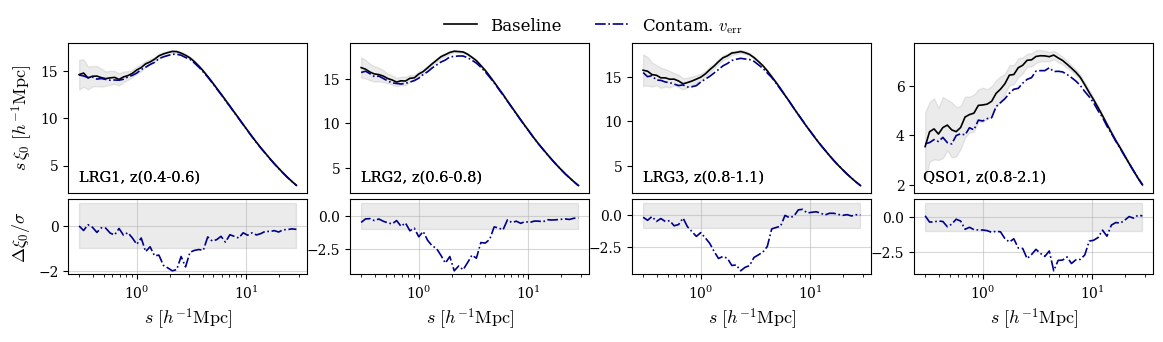

In [9]:
# for two point statistics
setup_logging(level='warning')

corr = 'mpslog0' # xi, pk, mpslog0， mpslog2, wplog, mesh2
domain = 'altmtl' # cubic, altmtl
version = 'AbacusHF-v2' # AbacusHF-v2, holi-v3
cov_version = 'holi-v3'
num_cov = 120
tracers = ['LRG', 'QSO'][:]
# tracers = ['BGS', 'ELG'][1:]
tracer_label = ''.join(t[0] for t in tracers)
zerrs =  ['False','verr_nonparam']
labels =  ['Baseline', r'Contam. $v_{\rm{err}}$', r'Contam. $v_{\rm{err, zevol}}$', r'Contam. $\Delta v_{\rm{rep}}$']
# labels = ['clean', '+dv_repeat', '+dv_repeat_zevol', '+dv_err_empirical', '+dv_err_nonparam', '+dv_err_nonparam_zevol']
colors = ['black', 'darkblue', 'darkgreen', 'maroon', 'teal', 'orange']
lss = ['-', '-.', '--', ':']*len(zerrs)
zerr_labels = dict(zip(zerrs, labels))
line_width = 1.2

use_jax = True if 'mesh' in corr else False
ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for indz, (zp, zr) in enumerate(zip(ZSNAPS[tracer][:], ZRANGES[tracer][:])):
        tracer_redshifts.append((f'{tracer}{indz+1}', zp, zr))
lenz = len(tracer_redshifts)

spow = 1
n_ell = 1
fig = plt.figure(figsize=(lenz * 3.5, 3.))
gs = gridspec.GridSpec(n_ell+1, lenz, wspace=0.18, hspace=0.06, height_ratios=[2]+[1]*n_ell)

ill = 0 if '0' in corr else 1
for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):    
    if tracer == 'QSO':
        remove_bins = 16
        domain = 'cutsky'
        hod = 'base_dv'
    else:
        remove_bins = 11
        domain = 'altmtl'
        hod = 'base'
    data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False, "use_jax": use_jax, "hod": hod}   
    cov_args = {'version': cov_version, 'domain': 'altmtl', 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False, "use_jax": use_jax}
    error_bar = get_error_bars(cov_args, corr[:6], num=num_cov, remove_bins=remove_bins)
    for indv, zerr in enumerate(zerrs):
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25)[:]:
            data_arges.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            fn = get_measurement_fn(**data_arges)
            (s, tps), _ = read_data_from_fn(fn, corr[:6], bin_type=BIN_TYPE, remove_bins=remove_bins, verbose=False)
            # for ell in range(n_ell):
                # ax_top.plot(s, s**spow*tps[ell], color=colors[indv], lw = 0.2, alpha=0.2)
            if tps is not None:
                tps_all.append(tps)
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        tps_std = tps_all.std(axis=0, ddof=1)
        if zerr == 'False':
            tps_mean_fid = tps_mean
            tps_std_fid = tps_std
        ax_top = plt.subplot(gs[indz])
        # ax_top.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
        ax_top.text(0.55, 0.15,f'{tracer}, z({zrange[0]:.1f}-{zrange[1]:.1f})',transform=ax_top.transAxes, ha='right', va='top', fontsize=10.5, )
        ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        # plot the mean plots
        if zerr == 'False':
            ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = '-',  lw = line_width, zorder=0, label=zerr_labels[zerr] if ill == 0 else None)
            ax_top.fill_between(s, s**spow*(tps_mean_fid[ill]-error_bar[ill]), s**spow*(tps_mean_fid[ill]+error_bar[ill]), color=colors[indv], alpha=alpha)
            # ax_top.errorbar(s, s**spow*tps_mean[ill], yerr=s**spow*error_bar[ill], fmt='o',linestyle='none', markersize=2, lw=1, color=colors[indv], label=zerr_labels[zerr] if ill == 0 else None)
        else:
            ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], lw = line_width, ls=lss[indv], label=zerr_labels[zerr] if ill == 0 else None)
        if corr in ['wplog', 'mpslog0', 'mpslog2']:
            ax_top.set_xscale('log')
        if indz == 0:
            ax_top.set_ylabel(TPS_LABELS[corr][f'y'], fontsize=13)
        # plot the residual plots
        if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
            ax_res = plt.subplot(gs[indz+lenz])
            if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr][f'dy'], fontsize=13)
            ax_res.set_xlabel(TPS_LABELS[corr]['x'], fontsize=13)
            ax_res.grid(alpha=0.5)
            ax_res.plot(s, (tps_mean[ill]-tps_mean_fid[ill])/error_bar[ill], lw=line_width, color=colors[indv], ls=lss[indv])  
            # for value in [-1,1]:
                # ax_res.axhline(y=value, ls = ':', color='black', lw=line_width)
            if zerr == 'verr_nonparam':
                ax_res.fill_between(s, -1, 1,  color='black', alpha=alpha)
            ax_res.set_xscale('log')
            # ax_res.set_xlim(s[0], s[-1])
        # ax_top.set_xlim(s[0], s[-1])
if corr == 'mpslog0':
    handles, legend_labels = ax_top.get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(zerrs), fontsize=12, frameon=False)
if save_fig == True and len(tracers) == 2:
    plt.savefig(OVERLEAF_DIR+f'/plot_{corr}_{tracer_label}_clustering.pdf', bbox_inches='tight')
plt.show()

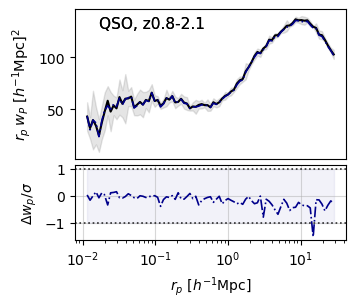

In [ ]:
# for projected correlation function
corr = 'wplog' # xi, pk, mpslog, wplog, mesh2
remove_bins = 12
domain = 'altmtl' # cubic, altmtl
version = 'AbacusHF-v2' # AbacusHF-v2, holi-v3
cov_version = 'AbacusHF-v2'
num_cov = 5
# tracers = ['BGS', 'LRG', 'ELG', 'QSO'][1:2]
tracers = ['LRG', 'QSO'][1:]
# tracers = ['BGS', 'ELG'][1:]
tracer_label = ''.join(t[0] for t in tracers)
zerrs =  ['False','verr_nonparam']
labels =  ['clean', r'$+\Delta v_{\rm{error}}$']
# labels = ['clean', '+dv_repeat', '+dv_repeat_zevol', '+dv_err_empirical', '+dv_err_nonparam', '+dv_err_nonparam_zevol']
colors = ['black', 'darkblue', 'darkgreen', 'maroon', 'teal', 'orange']
lss = ['-', '-.', '--', ':']*len(zerrs)
zerr_labels = dict(zip(zerrs, labels))

use_jax = True if 'mesh' in corr else False

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

spow = 1
n_ell = 1 if corr == 'wplog' else 2
fig = plt.figure(figsize=(lenz * 3.5, 3.))
gs = gridspec.GridSpec(n_ell+1, lenz, wspace=0.18, hspace=0.06, height_ratios=[2]+[1]*n_ell)

for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):    
    data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False, "use_jax": use_jax}   
    cov_args = {'version': cov_version, 'domain': domain, 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False, "use_jax": use_jax}
    error_bar = get_error_bars(cov_args, corr, num=num_cov, remove_bins=remove_bins)
    for indv, zerr in enumerate(zerrs):
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(5)[:]:
            data_arges.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            fn = get_measurement_fn(**data_arges)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test', remove_bins=remove_bins, verbose=False)
            # for ell in range(n_ell):
                # ax_top.plot(s, s**spow*tps[ell], color=colors[indv], lw = 0.2, alpha=0.2)
            tps = np.atleast_2d(tps)
            tps_all.append(tps)
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        tps_std = tps_all.std(axis=0, ddof=1)
        if zerr == 'False':
            tps_mean_fid = tps_mean
            tps_std_fid = tps_std
        ax_top = plt.subplot(gs[indz])
        # ax_top.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
        if tracer == 'LRG':
            ax_top.text(0.48, 0.15,f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}',transform=ax_top.transAxes, ha='right', va='top', fontsize=11, )
        elif tracer == 'QSO':
            ax_top.text(0.48, 0.95,f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}',transform=ax_top.transAxes, ha='right', va='top', fontsize=11, )
        ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        for ill in range(n_ell):
            # plot the mean plots
            if zerr == 'False':
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], ls = '-',  lw = 1.5, zorder=0)
                ax_top.fill_between(s, s**spow*(tps_mean_fid[ill]-error_bar[ill]), s**spow*(tps_mean_fid[ill]+error_bar[ill]), color=colors[indv], alpha=0.1, label=zerr_labels[zerr] if ill == 0 else None)
                # ax_top.errorbar(s, s**spow*tps_mean[ill], yerr=s**spow*error_bar[ill], fmt='o',linestyle='none', markersize=2, lw=1, color=colors[indv], label=zerr_labels[zerr] if ill == 0 else None)
            else:
                ax_top.plot(s, s**spow*tps_mean[ill], color=colors[indv], lw = 1.2, ls=lss[indv], label=zerr_labels[zerr] if ill == 0 else None)
            if corr in ['wplog', 'mpslog']:
                ax_top.set_xscale('log')
            if indz == 0:
                ax_top.set_ylabel(TPS_LABELS[corr]['y'], fontsize=10.5)
            # plot the residual plots
            if zerr in ['repeat', 'verr_empirical', 'verr_nonparam', 'verr_nonparam_zevol']:
                ax_res = plt.subplot(gs[indz+lenz])
                if indz == 0: ax_res.set_ylabel(TPS_LABELS[corr]['dy0'], fontsize=10)
                if corr == 'wplog':
                    ax_res.set_xlabel(TPS_LABELS[corr]['x'])
                # ax_res.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
                # continue
                # err = np.sqrt(tps_std_fid**2 + clean_std[ell]**2)
                ax_res.plot(s, (tps_mean[ill]-tps_mean_fid[ill])/error_bar[ill], lw=1.2, color=colors[indv], ls=lss[indv])  
                # ax.plot(s, s*(tps_mean[ill]-tps_mean_clean[ill]), lw=1, color=colors[indv])  
                for value in [-1,1]:
                    ax_res.axhline(y=value, ls = ':', color='black', lw=1.2, alpha=0.8)
                if zerr == 'verr_nonparam':
                    ax_res.fill_between(s, -1, 1,  color='darkblue', alpha=0.05)
                ax_res.grid(alpha=0.5)
                ax_res.set_xscale('log')
# handles, legend_labels = ax_top.get_legend_handles_labels()
# fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=len(zerrs), fontsize=11, frameon=False)
if save_fig == True and len(tracers) == 2:
    plt.savefig(OVERLEAF_DIR+f'/plot_{corr}_{tracer_label}_clustering.pdf', bbox_inches='tight')
plt.show()

## Relative plot

In [ ]:
# Residual plots only: (zerr - clean) / sigma_clean for mesh2
corr = 'mesh2'
domain = 'altmtl'
version = 'AbacusHF-v2'
cov_version = 'holi-v3'
tracers = ['LRG', 'QSO']

zerrs = ['False', 'verr_nonparam', 'verr_nonparam_zevol']

zerr_labels = {
    'False': 'clean',
    'verr_nonparam': r'$+dv_{\rm{err}}$',
    'verr_nonparam_zevol': r'$+dv_{\rm{err,zevol}}$',
}

colors = {
    'verr_nonparam': 'darkblue',
    'verr_nonparam_zevol': 'maroon',
}

lss = {
    'verr_nonparam': '-',
    'verr_nonparam_zevol': '--',
}

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

spow = 2 if corr in ['xi', 'wplog', 'mpslog'] else 1
n_ell = 1 if corr == 'wplog' else 2
fig = plt.figure(figsize=(lenz * 4.5, 4))
gs = gridspec.GridSpec(n_ell, lenz, wspace=0.15, hspace=0.05)
for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):
    # Read clean measurements
    clean_all = []
    tps_mean_fid = None
    data_args = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False}
    cov_args= {'version': cov_version, 'domain': domain, 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False}
    error_bar = get_error_bars(cov_args, corr)
    # Avoid divide-by-zero in residuals
    for zerr in zerrs:
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25):
            data_args.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol) 
            fn = get_measurement_fn(**data_args)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test')
            tps_all.append(np.atleast_2d(tps))
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        if zerr == 'False':
            tps_mean_fid = tps_mean
        else: 
            for ill in range(n_ell):
                ax = plt.subplot(gs[ill, indz])
                residual = (tps_mean[ill] - tps_mean_fid[ill]) / error_bar[ill]
                ax.plot(s, residual, color=colors[zerr], ls=lss[zerr], lw=1.5, label=zerr_labels[zerr],)
                ax.axhline(1, color='black', ls=':', lw=1.2)
                ax.axhline(-1, color='black', ls=':', lw=1.2)
                ax.grid(alpha=0.4)
                if corr in ['wplog', 'mpslog']:
                    ax.set_xscale('log')
                if ill == 0:
                    ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
                    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy0'])
                else:
                    ax.set_xlabel(TPS_LABELS[corr]['x'])
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy2'])
                ax.set_ylim(-3., 1.5)
                if ill == 1 and indz == 0:
                    ax.legend(loc=3, fontsize=10)
plt.show()

In [ ]:
# Residual plots only: (zerr - clean) / sigma_clean for mesh3
corr = 'mesh3_sugiyama'
domain = 'altmtl'
version = 'AbacusHF-v2'
cov_version = 'AbacusHF-v2'
tracers = ['LRG', 'QSO']

zerrs = ['False', 'verr_nonparam', 'verr_nonparam_zevol']

zerr_labels = {
    'False': 'clean',
    'verr_nonparam': r'$+dv_{\rm{err}}$',
    'verr_nonparam_zevol': r'$+dv_{\rm{err,zevol}}$',
}

colors = {
    'verr_nonparam': 'darkblue',
    'verr_nonparam_zevol': 'maroon',
}

lss = {
    'verr_nonparam': '-',
    'verr_nonparam_zevol': '--',
}

ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

ells = [(0, 0, 0), (2, 0, 2)]

n_ell = len(ells)
fig = plt.figure(figsize=(lenz * 4.5, 4))
gs = gridspec.GridSpec(n_ell, lenz, wspace=0.15, hspace=0.05)
for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):
    # Read clean measurements
    clean_all = []
    s_clean = None
    data_args = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False}
    cov_args= {'version': cov_version, 'domain': domain, 'tracer': tracer, 'zsnap': zsnap, 'zrange': zrange, 'use_dv': False, 'z_evol': False}
    error_bar = get_error_bars(cov_args, corr)
    for zerr in zerrs:
        tps_all = []
        use_dv, z_evol = parse_zerr_name(zerr)
        for mock_id in range(25):
            data_args.update(mock_id=mock_id, use_dv=use_dv, z_evol=z_evol)
            fn = get_measurement_fn(**data_args)
            (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test')
            tps_all.append(tps_to_array(tps, ells))
        tps_all = np.array(tps_all)
        tps_mean = tps_all.mean(axis=0)
        if zerr == 'False':
            tps_mean_fid = tps_mean
        else: 
            for ill in range(n_ell):
                ax = plt.subplot(gs[ill, indz])
                residual = (tps_mean[ill] - tps_mean_fid[ill]) / error_bar[ill]
                ax.plot(s, residual, color=colors[zerr], ls=lss[zerr], lw=1.5, label=zerr_labels[zerr],)
                ax.axhline(1, color='black', ls=':', lw=1.2)
                ax.axhline(-1, color='black', ls=':', lw=1.2)
                ax.grid(alpha=0.4)
                if corr in ['wplog', 'mpslog']:
                    ax.set_xscale('log')
                if ill == 0:
                    ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')
                    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy0'])
                else:
                    ax.set_xlabel(TPS_LABELS[corr]['x'])
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['dy2'])
                ax.set_ylim(-3.5, 1.5)
                if ill == 0 and indz == 0:
                    ax.legend(loc=3, fontsize=10)
plt.show()


## Plot all the holi-v3 mocks

[000208.92]  05-28 02:22  fit_tools                    WARNING  Failed to read /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/holi-v3/altmtl/LRG/mock565/mpspk/mesh2_spectrum_poles_LRG_z0.8-1.1_holi_v3.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/holi-v3/altmtl/LRG/mock565/mpspk/mesh2_spectrum_poles_LRG_z0.8-1.1_holi_v3.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


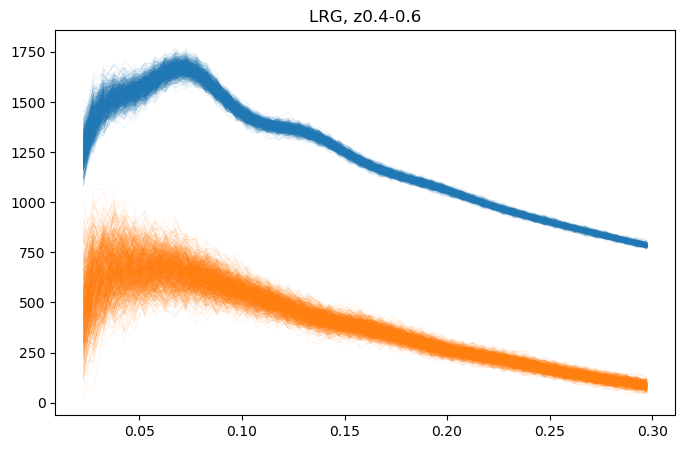

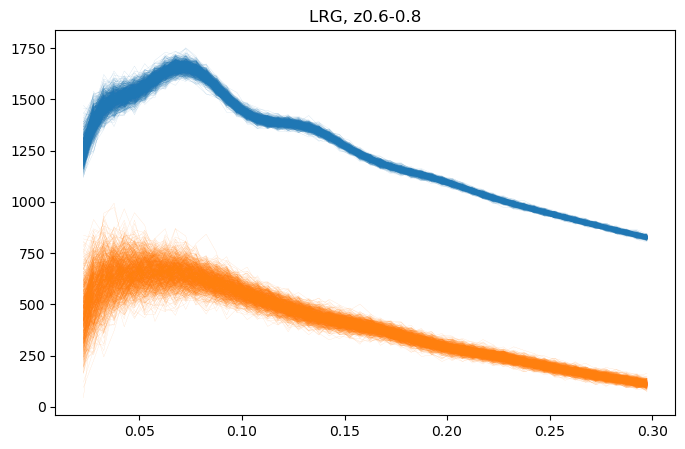

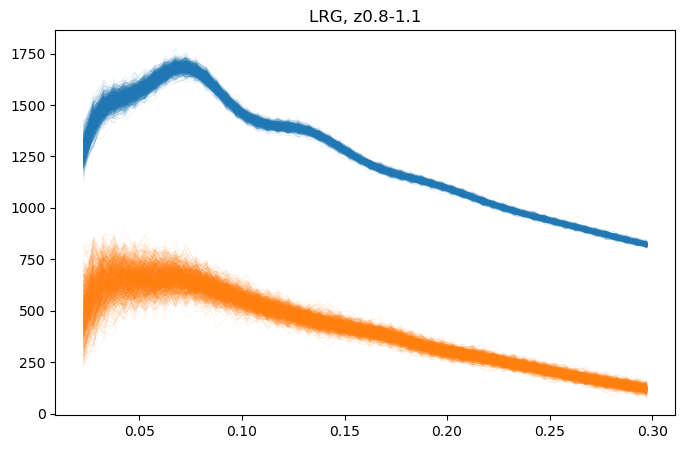

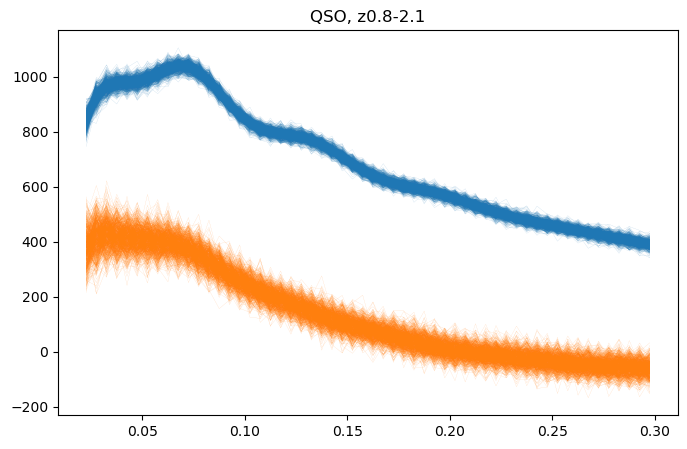

In [32]:
# for two point statistics
corr = 'mesh2' # xi, pk, mpslog, wplog, mesh2
domain = 'altmtl' # cubic, altmtl
version = 'holi-v3' # AbacusHF-v2, holi-v3
tracers = ['LRG', 'QSO'][:]
# tracers = ['BGS', 'ELG'][1:]
tracer_label = ''.join(t[0] for t in tracers)

use_jax = True if 'mesh' in corr else False
ZSNAPS, ZRANGES = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))
lenz = len(tracer_redshifts)

spow = 2 if corr in ['xi', 'wplog', 'mpslog'] else 1
n_ell = 1 if corr == 'wplog' else 2

for indz, (tracer, zsnap, zrange) in enumerate(tracer_redshifts):    
    fig = plt.figure(figsize=(8, 5))
    args = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, "use_dv": False, "z_evol": False, "use_jax": use_jax}  
    s = None
    tps = None
    for mock_id in range(1000)[:]:
        if mock_id in SKIP_HOLI_ID_SET and args['version'] == 'holi-v3':
            continue
        args.update(mock_id=mock_id, use_dv=False, z_evol=False)
        fn = get_measurement_fn(**args)
        (s, tps), _ = read_data_from_fn(fn, corr, bin_type='test', verbose=False)
        for ill in range(n_ell):
            if s is None:
                continue
            plt.plot(s, s**spow*tps[ill], color=f'C{ill}', lw = 0.1, alpha=0.5)
    plt.title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}')

In [29]:
SKIP_HOLI_ID_SET = np.append(SKIP_HOLI_ID_SET, 363)

In [30]:
SKIP_HOLI_ID_SET

array([  2,   5,   8,   9,  17,  26,  34,  47,  50,  51,  54,  62,  66,
        71,  73,  76,  78,  97, 106, 114, 121, 122, 131, 140, 142, 146,
       148, 149, 152, 155, 163, 166, 176, 184, 191, 194, 202, 208, 210,
       218, 234, 248, 260, 264, 269, 296, 298, 299, 320, 326, 330, 331,
       337, 349, 358, 371, 376, 378, 379, 384, 389, 391, 392, 408, 409,
       423, 425, 429, 430, 437, 438, 444, 447, 448, 452, 458, 470, 473,
       477, 487, 512, 515, 522, 530, 531, 532, 542, 553, 562, 566, 571,
       573, 591, 595, 597, 609, 611, 623, 624, 625, 634, 637, 638, 643,
       644, 649, 655, 657, 664, 667, 671, 679, 682, 690, 693, 698, 699,
       704, 707, 713, 716, 718, 727, 741, 746, 766, 770, 776, 784, 788,
       793, 802, 815, 824, 835, 846, 850, 864, 867, 879, 880, 882, 893,
       903, 919, 923, 928, 932, 951, 953, 971, 977, 982, 983, 363])

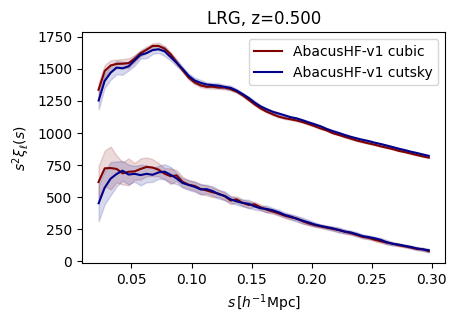

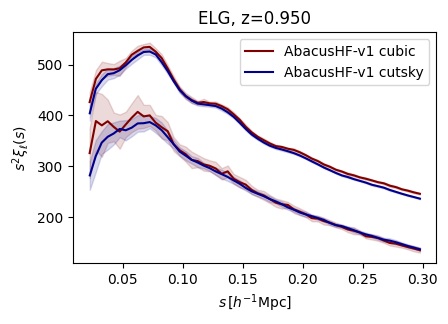

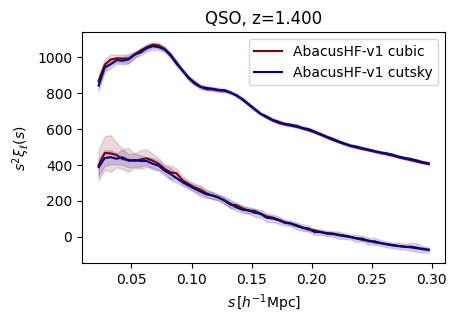

In [ ]:
# for power spectrum
corr = 'pk'

tracers = ['LRG', 'ELG', 'QSO']
# tracers = ['QSO']

for tracer in tracers:
    fig = plt.figure(figsize = (15, 3))
    gs = gridspec.GridSpec(1, 3, wspace=0.1, width_ratios=[1, 1, 1])
    for indz, zsnap in enumerate(REDSHIFT_ABACUSHF_v1[tracer][:1]):
        (z1, z2) = REDSHIFT_BIN_LSS[tracer][indz]
        colors = ['maroon', 'darkblue']
        for ind_in, domain in enumerate(['cubic', 'cutsky']):
            if domain == 'cubic':
                fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}.csv'
            elif domain == 'cutsky':
                fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}.csv'
                # suffix = '_bin'
                # fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_r{rmin}-{rmax}_zobs{z1:.1f}-{z2:.1f}{suffix}.csv'
            # --- load fiducial stats ---
            tab_fid = Table.read(fn, format='ascii.csv')
            k        = np.array(tab_fid['k'])
            for ell in [0,2]:
                pk_ell_mean = np.array(tab_fid[f'{corr}{ell}_mean'])
                pk_ell_std   = np.array(tab_fid[f'{corr}{ell}_std'])
                if ell == 0:
                    label = f'AbacusHF-v1 {domain}'
                else:
                    label = None
                # plot the multipole and quadrupoles
                ax = plt.subplot(gs[indz])
                ax.fill_between(k, k*(pk_ell_mean-pk_ell_std),k*(pk_ell_mean+pk_ell_std), color=colors[ind_in], alpha=0.15)
                ax.plot(k, k*pk_ell_mean, color=colors[ind_in], label=label, alpha=1.0)
                if indz == 0:
                    ax.set_ylabel(r"$s^2\xi_\ell(s)$")
                ax.set_xlabel(r"$s\,[h^{-1}\mathrm{Mpc}]$")
                ax.set_title(f"{tracer}, z={zsnap:.3f}")
                ax.legend()
                # ax.grid(alpha=0.3)

# Box clustering

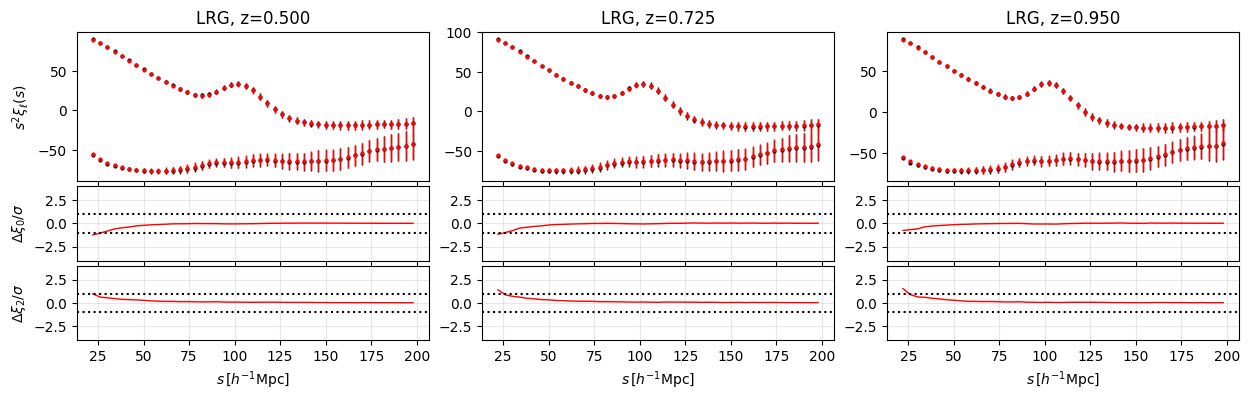

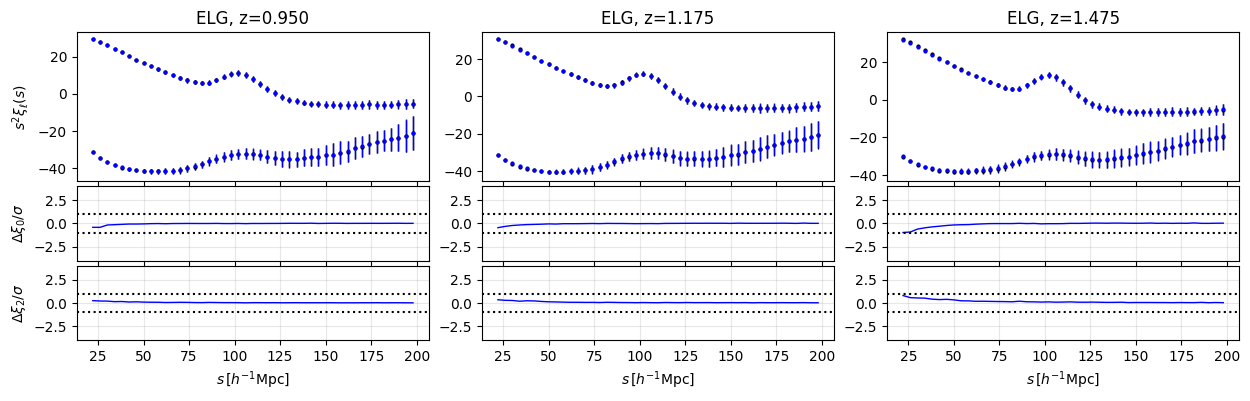

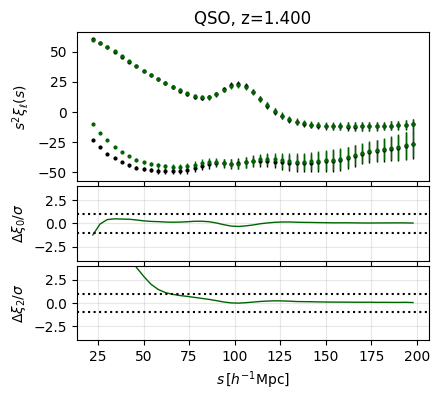

In [ ]:
# for two point correlation function

corr = 'xi'
# rcut = [60, 160]
rcut = None

tracers = ['LRG', 'ELG', 'QSO']

for tracer in tracers:
    fig = plt.figure(figsize = (15, 4))
    gs = gridspec.GridSpec(3, 3, wspace=0.15, hspace= 0.05, width_ratios=[1, 1, 1], height_ratios=[2,1,1])
    for indz, zsnap in enumerate(REDSHIFT_ABACUSHF_v1[tracer]):
        (z1, z2) = REDSHIFT_BIN_LSS[tracer][indz]
        colors = ['black', COLOR_OVERALL[tracer]]
        clean_mean = {}
        clean_std  = {}
        for inde, zerr in enumerate([False, True]):
            fn = RESULT_DIR+ f'/{corr}poles_cubic_{tracer}_z{zsnap:.3f}_DR2_v1.0_r{rmin}-{rmax}.csv'
            if zerr == True: fn = RESULT_DIR+ f'/{corr}poles_cubic_{tracer}_z{zsnap:.3f}_DR2_v1.0_r{rmin}-{rmax}_zobs{z1:.1f}-{z2:.1f}.csv'
            # --- load fiducial stats ---
            tab_fid = Table.read(fn, format='ascii.csv')
            r        = np.array(tab_fid['r'])
            if rcut is not None:
                mask = (r>rcut[0])&(r < rcut[1])
                tab_fid = tab_fid[mask]
                r = r[mask]
            for ell in [0,2]:
                xi_ell_mean = np.array(tab_fid[f'xi{ell}_mean'])
                xi_ell_std   = np.array(tab_fid[f'xi{ell}_std'])
                if not zerr:
                    # store clean multipole for this ell
                    clean_mean[ell] = xi_ell_mean.copy()
                    clean_std[ell]  = xi_ell_std.copy()
                # plot the multipole and quadrupoles
                ax = plt.subplot(gs[indz])
                ax.errorbar(r, r**2 * xi_ell_mean, yerr=r**2 * xi_ell_std, 
                            fmt='o', markersize=2, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)
                ax.set_title(f"{tracer}, z={zsnap:.3f}")
                if indz == 0 and ell == 0:
                    ax.set_ylabel(r"$s^2\xi_\ell(s)$")
                # plot the residual plots
                if zerr is not False:
                    if ell == 0:
                        ax = plt.subplot(gs[indz+3])
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta\xi_0/\sigma$")
                    elif ell == 2:
                        ax = plt.subplot(gs[indz+6])
                        ax.set_xlabel(r"$s\,[h^{-1}\mathrm{Mpc}]$")
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta\xi_2/\sigma$")
                    err = np.sqrt(xi_ell_std**2 + clean_std[ell]**2)
                    ax.plot(r, (xi_ell_mean - clean_mean[ell])/err, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)  
                    for value in [-1,1]:
                        ax.axhline(y=value, ls = ':', color='black')
                    ax.set_ylim([-4,4])
                    ax.grid(alpha=0.3)

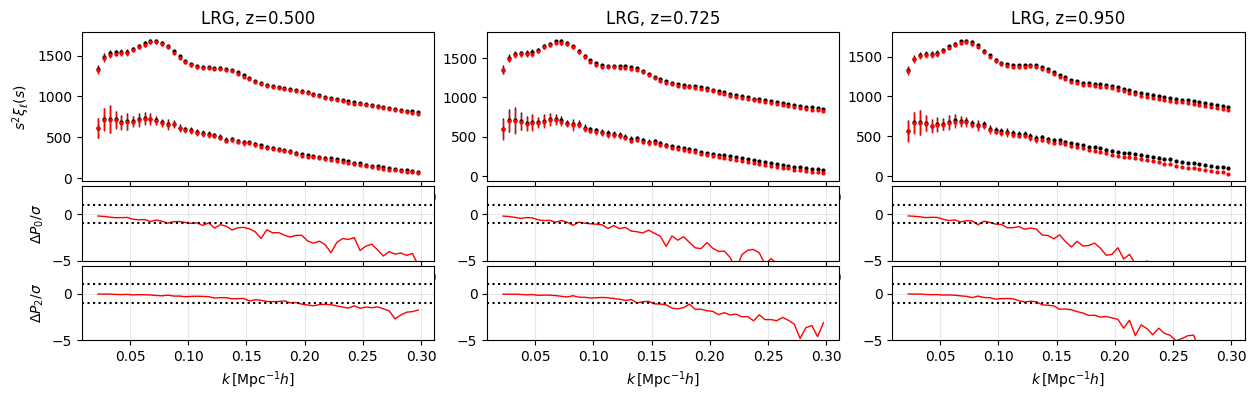

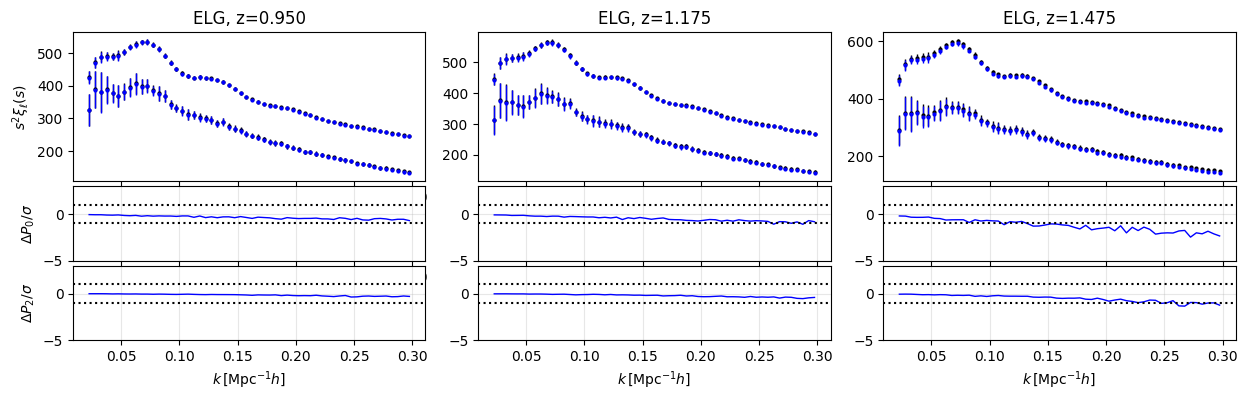

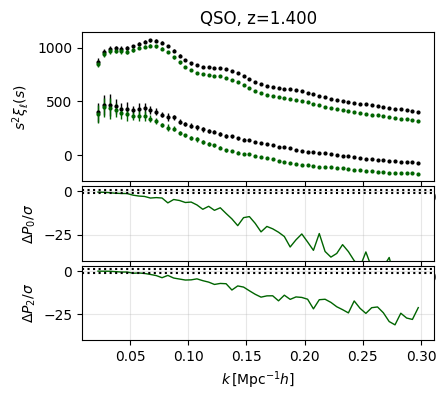

In [54]:
# for power spectrum
corr = 'pk'
# kcut = [0.02, 0.2]
kcut = None

tracers = ['LRG', 'ELG', 'QSO']

for tracer in tracers:
    fig = plt.figure(figsize = (15, 4))
    gs = gridspec.GridSpec(3, 3, wspace=0.15, hspace= 0.05, width_ratios=[1, 1, 1], height_ratios=[2,1,1])
    for indz, zsnap in enumerate(REDSHIFT_ABACUSHF_v1[tracer]):
        (z1, z2) = REDSHIFT_BIN_LSS[tracer][indz]
        colors = ['black', COLOR_OVERALL[tracer]]
        clean_mean = {}
        clean_std  = {}
        for inde, zerr in enumerate([False, True]):
            fn = RESULT_DIR+ f'/{corr}poles_cubic_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}.csv'
            if zerr == True: fn = RESULT_DIR+ f'/{corr}poles_cubic_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}_zobs{z1:.1f}-{z2:.1f}.csv'
            # --- load fiducial stats ---
            tab_fid = Table.read(fn, format='ascii.csv')
            k       = np.array(tab_fid['k'])
            if kcut is not None:
                mask = (k>kcut[0])&(k < kcut[1])
                tab_fid = tab_fid[mask]
                k = k[mask]
            for ell in [0,2]:
                pk_ell_mean = np.array(tab_fid[f'pk{ell}_mean'])
                pk_ell_std   = np.array(tab_fid[f'pk{ell}_std'])
                if zerr is False:
                    clean_mean[ell] = pk_ell_mean.copy()
                    clean_std[ell] = pk_ell_std.copy()
                # plot the multipole and quadrupoles
                ax = plt.subplot(gs[indz])
                ax.errorbar(k, k * pk_ell_mean, yerr=k * pk_ell_std, 
                            fmt='o', markersize=2, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)
                if indz == 0 and ell == 0:
                    ax.set_ylabel(r"$s^2\xi_\ell(s)$")
                ax.set_title(f"{tracer}, z={zsnap:.3f}")
                # plot the residual plots
                if zerr is not False:
                    if ell == 0:
                        ax = plt.subplot(gs[indz+3])
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta P_0/\sigma$")
                    elif ell == 2:
                        ax = plt.subplot(gs[indz+6])
                        ax.set_xlabel(r"$k\,[\mathrm{Mpc} ^{-1}h]$")
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta P_2/\sigma$")
                    # err = np.sqrt(pk_ell_std**2+clean_std[ell]**2)
                    err = clean_std[ell]
                    ax.plot(k, (pk_ell_mean-clean_mean[ell])/err, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)  
                    for value in [-1,1]:
                        ax.axhline(y=value, ls = ':', color='black')
                    ax.set_ylim([-40 if tracer == 'QSO' else -5,3])
                    ax.grid(alpha=0.3)

In [ ]:
dv low redshift small 
dv high redshift larger

dz = dv * (1+z) /c 

NameError: name 'dv' is not defined

# Cutsky clustering

[000784.25]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.25]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.30]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.31]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.


[000784.36]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.36]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.42]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.42]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.47]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.48]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.53]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.53]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[000784.59]  12-08 06:52  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[

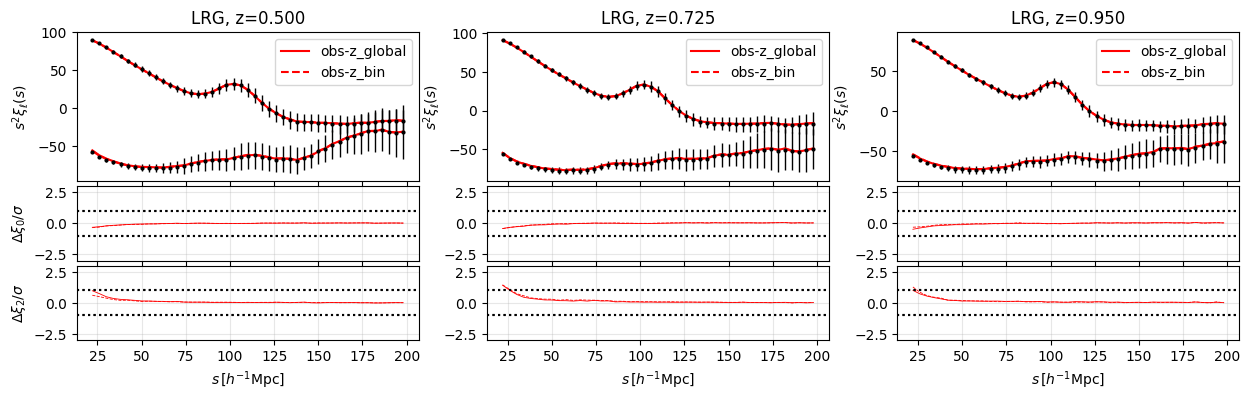

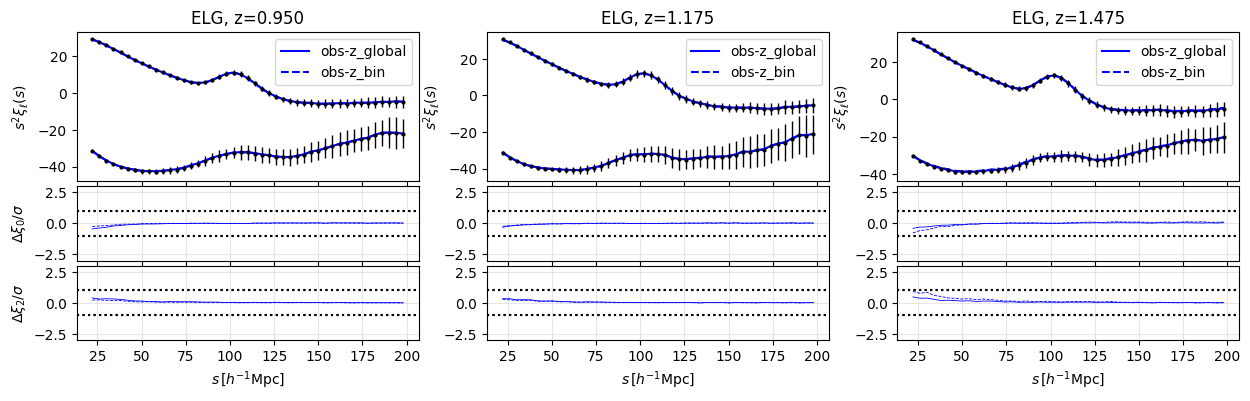

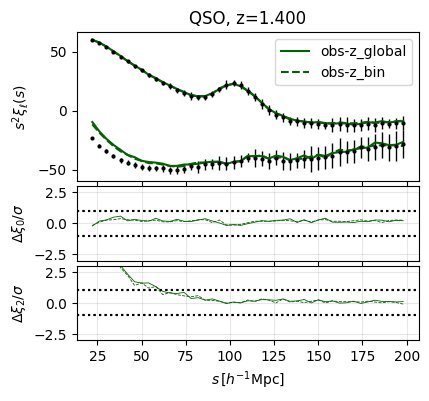

In [ ]:
# for two point correlation function

corr = 'xi'
domain = 'cutsky'
# rcut = [60, 160]
rcut = None

tracers = ['LRG', 'ELG', 'QSO']

for tracer in tracers:
    fig = plt.figure(figsize = (15, 4))
    gs = gridspec.GridSpec(3, 3, wspace=0.2, hspace= 0.05, width_ratios=[1, 1, 1], height_ratios=[2,1,1])
    for indz, zsnap in enumerate(REDSHIFT_ABACUSHF_v1[tracer]):
        clean_mean = {}
        clean_std  = {}
        (z1, z2) = REDSHIFT_BIN_LSS[tracer][indz]
        colors = ['black', COLOR_OVERALL[tracer], COLOR_OVERALL[tracer]]
        lss = ['-', '-', '--']
        for inde, zerr in enumerate([False, 'global', 'bin']):
            fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_r{rmin}-{rmax}.csv'
            label = None
            if zerr is not False:
                fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_r{rmin}-{rmax}_zobs{z1:.1f}-{z2:.1f}_{zerr}.csv'
                label = f'obs-z_{zerr}'
            # --- load fiducial stats ---
            tab_fid = Table.read(fn, format='ascii.csv')
            r        = np.array(tab_fid['r'])
            if rcut is not None:
                mask = (r>rcut[0])&(r < rcut[1])
                tab_fid = tab_fid[mask]
                r = r[mask]
            for ell in [0,2]:
                xi_ell_mean = np.array(tab_fid[f'xi{ell}_mean'])
                xi_ell_std   = np.array(tab_fid[f'xi{ell}_std'])
                if not zerr:
                    # store clean multipole for this ell
                    clean_mean[ell] = xi_ell_mean.copy()
                    clean_std[ell]  = xi_ell_std.copy()
                # plot the multipole and quadrupoles
                ax = plt.subplot(gs[indz])
                # ax.errorbar(r, r**2 * xi_ell_mean, yerr=r**2 * xi_ell_std, 
                            # fmt='o', markersize=2, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)
                if zerr == False:
                    ax.errorbar(r, r**2 * xi_ell_mean, yerr=r**2 * xi_ell_std, fmt='o', markersize=2, lw=1, color=colors[inde])
                else:
                    ax.plot(r, r**2* xi_ell_mean, color=colors[inde], ls=lss[inde], label = label if ell == 0 else None)
                if inde == 0:
                    ax.set_ylabel(r"$s^2\xi_\ell(s)$")
                ax.legend(loc=1)
                ax.set_title(f"{tracer}, z={zsnap:.3f}")
                # plot the residual plots
                if zerr is not False:
                    if ell == 0:
                        ax = plt.subplot(gs[indz+3])
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta\xi_0/\sigma$")
                    elif ell == 2:
                        ax = plt.subplot(gs[indz+6])
                        ax.set_xlabel(r"$s\,[h^{-1}\mathrm{Mpc}]$")
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta\xi_2/\sigma$")
                    err = np.sqrt(xi_ell_std**2 + clean_std[ell]**2)
                    ax.plot(r, (xi_ell_mean - clean_mean[ell])/err,  ls=lss[inde], lw=0.6, color=colors[inde])  
                    for value in [-1,1]:
                        ax.axhline(y=value, ls = ':', color='black')
                    ax.set_ylim([-3,3])
                    ax.grid(alpha=0.3)

[001053.50]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[001053.51]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.


[001053.55]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[001053.56]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[001053.61]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.
[001053.62]  12-08 06:56  matplotlib.legend            WARNING  No handles with labels found to put in legend.


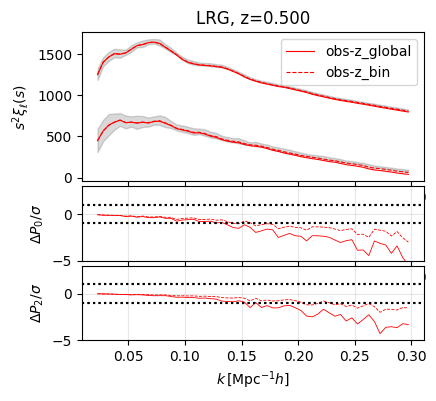

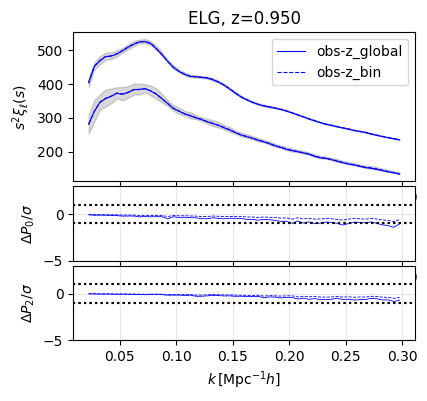

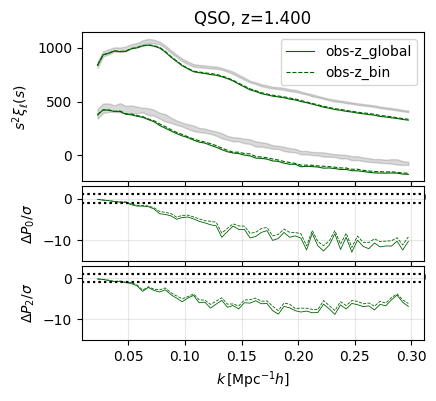

In [29]:
# for power spectrum
corr = 'pk'
# kcut = [0.02, 0.2]
kcut = None

tracers = ['LRG', 'ELG', 'QSO']

for tracer in tracers:
    fig = plt.figure(figsize = (15, 4))
    gs = gridspec.GridSpec(3, 3, wspace=0.2, hspace= 0.05, width_ratios=[1, 1, 1], height_ratios=[2,1,1])
    for indz, zsnap in enumerate(REDSHIFT_ABACUSHF_v1[tracer][:1]):
        clean_mean = {}
        clean_std  = {}
        (z1, z2) = REDSHIFT_BIN_LSS[tracer][indz]
        colors = ['black', COLOR_OVERALL[tracer], COLOR_OVERALL[tracer]]
        lss = ['-', '-', '--']
        for inde, zerr in enumerate([False, 'global', 'bin']):
            fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}.csv'
            label = None
            if zerr is not False:
                fn = RESULT_DIR+ f'/{corr}poles_{domain}_{tracer}_z{zsnap:.3f}_DR2_v1.0_k{kmin}-{kmax}_zobs{z1:.1f}-{z2:.1f}_{zerr}.csv'
                label = f'obs-z_{zerr}'
            # --- load fiducial stats ---
            tab_fid = Table.read(fn, format='ascii.csv')
            k       = np.array(tab_fid['k'])
            if kcut is not None:
                mask = (k>kcut[0])&(k < kcut[1])
                tab_fid = tab_fid[mask]
                k = k[mask]
            for ell in [0,2]:
                pk_ell_mean = np.array(tab_fid[f'{corr}{ell}_mean'])
                pk_ell_std   = np.array(tab_fid[f'{corr}{ell}_std'])
                if zerr is False:
                    clean_mean[ell] = pk_ell_mean.copy()
                    clean_std[ell] = pk_ell_std.copy()
                # plot the multipole and quadrupoles
                ax = plt.subplot(gs[indz])
                if zerr == False:
                    ax.fill_between(k, k*(pk_ell_mean-pk_ell_std),  k*(pk_ell_mean+pk_ell_std), color=colors[inde], alpha = 0.15)
                    # ax.errorbar(k, k*(pk_ell_mean), yerr= k*pk_ell_std,  fmt='o', markersize=2, lw=1, color=colors[inde])
                else:
                    ax.plot(k, k*pk_ell_mean, color=colors[inde], lw = 0.8, ls=lss[inde], label = label if ell == 0 else None)
                if indz == 0 and ell == 0:
                    ax.set_ylabel(r"$s^2\xi_\ell(s)$")
                ax.legend(loc=1)
                ax.set_title(f"{tracer}, z={zsnap:.3f}")
                # plot the residual plots
                if zerr is not False:
                    if ell == 0:
                        ax = plt.subplot(gs[indz+3])
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta P_0/\sigma$")
                    elif ell == 2:
                        ax = plt.subplot(gs[indz+6])
                        ax.set_xlabel(r"$k\,[\mathrm{Mpc} ^{-1}h]$")
                        if indz == 0:
                            ax.set_ylabel(r"$\Delta P_2/\sigma$")
                    # err = np.sqrt(pk_ell_std**2+clean_std[ell]**2)
                    err = clean_std[ell]
                    # ax.plot(k, (pk_ell_mean-clean_mean[ell])/err, lw=1, color=colors[inde], label=f'fid ξ{ell}' if indz == 0 else None)  
                    ax.plot(k, (pk_ell_mean - clean_mean[ell])/err,  ls=lss[inde], lw=0.6, color=colors[inde])  
                    for value in [-1,1]:
                        ax.axhline(y=value, ls = ':', color='black')
                    ax.set_ylim([-15 if tracer == 'QSO' else -5,3])
                    ax.grid(alpha=0.3)
                if indz == 0 and ell==0:
                    ax = plt.subplot(gs[indz+3])

## Consistent check with jaxpower and pypower

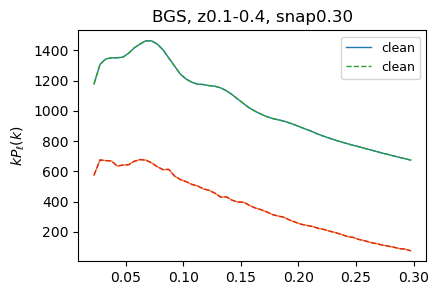

In [ ]:

# for two point statistics
domain = 'cubic'
version = 'AbacusHF-v2'
tracers = ['BGS','LRG', 'ELG', 'QSO'][:1]

ZSNAPS, ZRANGES = REDSHIFT_ABACUSHF[version]
lenz = len(ZSNAPS)

zerrs =  ['False', 'repeat', 'verr_empirical'][:1]

colors = ['black', 'maroon', 'darkblue']
labels = ['clean', '+dv_repeats', '+dv_err']
zerr_labels = dict(zip(zerrs, labels))

for tracer in tracers:
    fig = plt.figure(figsize = (lenz*5, 3))
    gs = gridspec.GridSpec(1, lenz, wspace=0.15, hspace= 0.05)
    for indz, zsnap, zrange in zip(range(lenz), ZSNAPS[tracer][:], ZRANGES[tracer][:]):
        for indv, zerr in enumerate(zerrs):
            for corr in ['pk', 'mesh2']:
                s_all = []
                tps_all = []
                for mock_id in range(25)[:]:
                    data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, 'mock_id': mock_id, "use_dv": zerr}
                    if corr in ['mesh2']: data_arges.update(use_jax=True)
                    fn = get_measurement_fn(**data_arges)
                    setup_logging(level = 'warning')
                    (s, tps), _ = read_measurement_from_fn(fn, corr, bin_type='y3_sys')
                    tps = np.atleast_2d(tps)
                    tps_all.append(tps)
                tps_all = np.array(tps_all)
                tps_mean = tps_all.mean(axis=0)
                tps_std = tps_all.std(axis=0, ddof=1)
                spow=2 if corr in ['xi', 'wplog', 'mpslog'] else 1
                n_ell = 1 if corr == 'wplog' else 2
                for ill in range(n_ell):
                    # plot the mean plots
                    ax = plt.subplot(gs[indz])
                    if zerr == 'False':
                        tps_mean_clean = tps_mean
                        tps_std_clean = tps_std
                        # ax.fill_between(s, s**spow*(tps_mean_fid[ill]-tps_std_fid[ill]),s**spow*(tps_mean_fid[ill]+tps_std_fid[ill]), color=colors[indv], alpha=0.15)
                        # ax.errorbar(s, s**spow*tps_mean_clean[ill], yerr=s**spow*tps_std_clean[ill], fmt='o', markersize=2, lw=1, label=zerr_labels[zerr] if ill == 0 else None)
                    # else:
                    ax.plot(s, s**spow*tps_mean[ill], ls = '-' if cor == 'pk' else '--', lw = 1, label=zerr_labels[zerr] if ill == 0 else None)
                    if corr in ['wplog', 'mpslog']:
                        ax.set_xscale('log')
                    if indz == 0:
                        ax.set_ylabel(TPS_LABELS[corr]['y'])
                    ax.legend(loc=2 if corr in ['wplog', 'mpslog'] else 1, fontsize=9)
                    ax.set_title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}, snap{zsnap:.2f}')
                    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/pkpoles_LRG_z0.4-0.6_DR2_v2.0.npy'

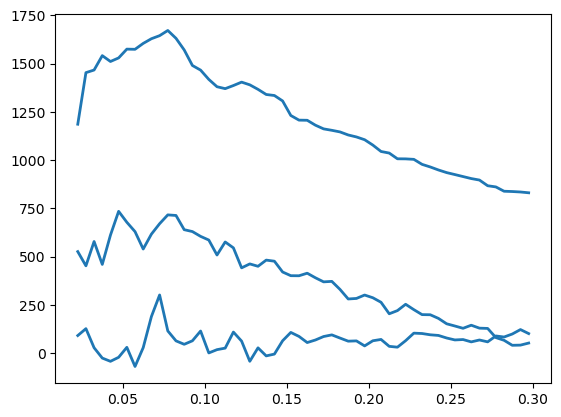

In [4]:


for i in range(20):
    tracer = 'LRG'
    ZSNAPS, ZRANGES = REDSHIFT_ABACUSHF[version]

    indz = 0
    zsnap = ZSNAPS[tracer][indz]
    zrange = ZRANGES[tracer][indz]
    for mock_id in range(25)[i:i+1]:
        corr = 'mesh2'
        data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, 'mock_id': mock_id, "use_dv": zerr}
        if corr in ['mesh2']: data_arges.update(use_jax=True)
        fn = get_measurement_fn(**data_arges)
        setup_logging(level = 'warning')
        (s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')
        plt.plot(s, s*tps[0], color = 'C0', ls = '-', lw=2, label = 'jaxpower')
        plt.plot(s, s*tps[1], color = 'C0', ls = '-', lw=2)
        plt.plot(s, s*tps[2], color = 'C0', ls = '-', lw=2)

        corr = 'pk'
        data_arges = {'version':version, 'domain':domain, 'tracer':tracer, 'zsnap': zsnap, 'zrange':zrange, 'mock_id': mock_id, "use_dv": zerr}
        fn = get_measurement_fn(**data_arges)
        setup_logging(level = 'warning')
        (s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')
        plt.plot(s, s*tps[0], color = 'C1', ls = '--', lw=1.5, label = 'pypower')
        plt.plot(s, s*tps[1], color = 'C1', ls = '--', lw=1.5)
        plt.plot(s, s*tps[2], color = 'C1', ls = '--', lw=1.5)

        corr = 'mesh2'
        if tracer == 'BGS': tracer = 'BGS-21.35'
        fn = f'/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacushf/measurements/v2/mesh2_spectrum_poles_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_c000_base_losz_{mock_id}.h5'
        (s, tps), _ = read_data_from_fn(fn, corr, bin_type='y3_sys')
        plt.plot(s, s*tps[0], color = 'C3', ls = ':', lw=1.5, label = 'pre saved')
        plt.plot(s, s*tps[1], color = 'C3', ls = ':', lw=1.5)
        plt.plot(s, s*tps[2], color = 'C3', ls = ':', lw=1.5)
        plt.legend()
        plt.title(f'{tracer}, z{zrange[0]:.1f}-{zrange[1]:.1f}, snap{zsnap:.2f}, mock{mock_id}, base')
        plt.show()

## APPENDIX